month_number      0     1
cohort                   
2023-01        95.8  12.5
2023-02        95.9  22.4
2023-03        91.7  27.8
2023-04        90.6  20.8
2023-05        88.6  27.3
2023-06        91.9  24.3
2023-07        97.5  12.5
2023-08        92.5  17.0
2023-09        90.0  22.5
2023-10        96.9  18.8
2023-11       100.0  17.2
2023-12        92.7  14.6
2024-01        91.3  21.7
2024-02        97.5   7.5
2024-03        91.9  27.0
2024-04        97.7  11.6
2024-05        96.0  20.0
2024-06        77.4  32.3
2024-07        93.5  19.6
2024-08        88.0  44.0
2024-09        94.9  25.6
2024-10        94.4  18.5
2024-11        92.2  27.5
2024-12        94.4   0.0


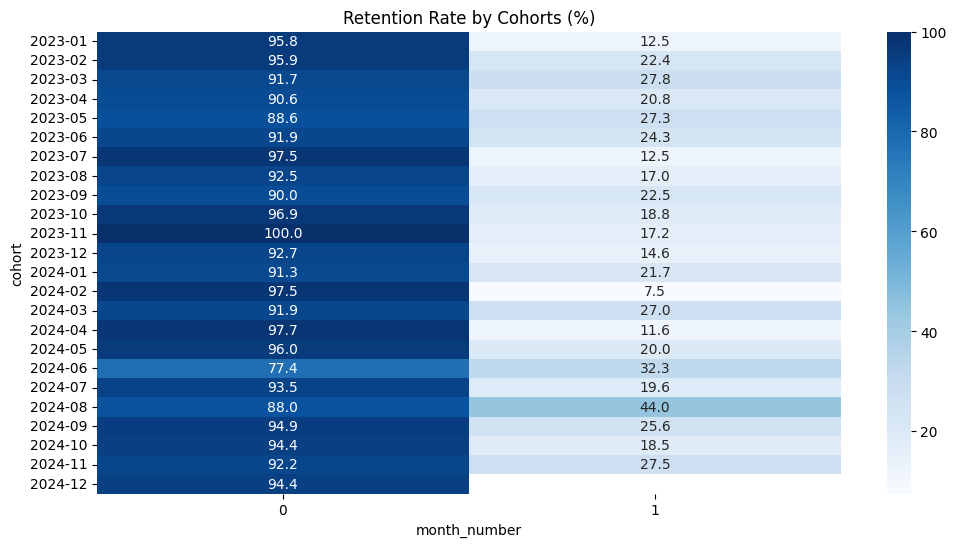

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns


# Создаём 1000 пользователей с датой регистрации в 2023-2024 годах
np.random.seed(42)
dates = pd.date_range('2023-01-01', '2024-12-31', freq='D')
users = pd.DataFrame({
    'user_id': range(1, 1001),
    'reg_date': np.random.choice(dates, 1000)
})

# Для каждого пользователя генерируем логины (действия) в последующие дни
actions = []
for user in users.itertuples():
    n_actions = np.random.poisson(5)  # в среднем 5 действий
    for _ in range(n_actions):
        days_after = np.random.geometric(0.3)  # большинство действий в первые дни
        action_date = user.reg_date + timedelta(days=int(days_after))
        if action_date <= datetime(2024,12,31):
            actions.append({'user_id': user.user_id, 'action_date': action_date})

actions_df = pd.DataFrame(actions)

# Определяем когорту по году и месяцу регистрации
users['cohort'] = users['reg_date'].dt.to_period('M')

# Добавляем месяц действия каждому событию
actions_df['action_month'] = actions_df['action_date'].dt.to_period('M')

# Для каждого действия вычисляем относительный месяц жизни (0,1,2,...)
actions_df = actions_df.merge(users[['user_id','cohort']], on='user_id')
actions_df['month_number'] = (actions_df['action_month'] - actions_df['cohort']).apply(lambda x: x.n)

# Считаем количество уникальных пользователей, совершивших действие в каждом месяце жизни когорты
retention = actions_df.groupby(['cohort','month_number'])['user_id'].nunique().reset_index()

# Формируем сводную таблицу: строки – когорты, столбцы – месяцы жизни
retention_pivot = retention.pivot(index='cohort', columns='month_number', values='user_id')

# Берём за 100% размер самой когорты
cohort_sizes = users.groupby('cohort')['user_id'].nunique()
retention_rate = retention_pivot.divide(cohort_sizes, axis=0) * 100

print(retention_rate.round(1).fillna(0))

plt.figure(figsize=(12,6))
sns.heatmap(retention_rate, annot=True, fmt='.1f', cmap='Blues')
plt.title('Retention Rate by Cohorts (%)')
plt.show()